# Packages

Imported functions and modules are used for solving the exam.

In [1]:
import os

from codelib.file_management.dynamic_file_pathing import get_root

root = get_root()
data_folder = os.path.join(root, "GBI Optimisation", "Data")

import sys
sys.path.insert(0,r"C:\Users\thorb\Documents\Github Repositories\AEF_thesis_GBI")

In [2]:
from typing import Union 

# numpy for working with matrices, etc. 
import numpy as np

# import pandas
import pandas as pd

# plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# scipy for statistics and optimization
from scipy import optimize
from scipy import stats

# import cvxpy
import cvxpy as cp

# function to perform interpolation

"""
functions from codelib
"""

# functions for calculating moments
from codelib.Johan.statistics import moments as mom

# functions for calculating risk metrics
from codelib.Johan.portfolio_optimization import risk_metrics as rm

# functions for risk budgetting
from codelib.Johan.portfolio_optimization import risk_metrics as rb

# functions for mean-variance optimization
from codelib.Johan.portfolio_optimization import mean_variance as mvo

# cash flows
from codelib.Johan.fixed_income.cash_flows import CashFlow

# predefined plots
from codelib.Johan.visualization.base import fan_chart

np.random.seed(321)

# Portfolio optimization

Assume that the yearly linear return follows a log-normal distribution. The excel-file _data.xlsx_ contains the expected one year discrete return, the volatility and correlation of the one discrete return, and the yearly cost.

## Load data

In [3]:
data_path = os.path.join(data_folder, "Afkvastforventingerne.xlsx")

asset_names = pd.read_excel(data_path, sheet_name='Returns', index_col=0).index.values.flatten()
num_assets = len(asset_names)

asset_indices = {k: i for i, k in enumerate(asset_names)}

mu_linear_1y = pd.read_excel(data_path, sheet_name='Returns', index_col=0).values.flatten()

corr_mat_linear_1y = pd.read_excel(data_path, sheet_name='Correlation', index_col=0).values
corr_mat_linear_1y[np.tril_indices_from(corr_mat_linear_1y, k=-1)] = corr_mat_linear_1y.T[np.tril_indices_from(corr_mat_linear_1y, k=-1)]

vols_linear_1y = pd.read_excel(data_path, sheet_name='Volatility', index_col=0).values.flatten()
costs_linear_1y = pd.read_excel(data_path, sheet_name='Cost', index_col=0).values.flatten()

## Calculate covariance matrix

In [4]:
cov_mat_linear_1y = mom.corr_to_cov_matrix(corr_mat_linear_1y, vols_linear_1y)

In [5]:
# show covariance matrix
pd.DataFrame(cov_mat_linear_1y, columns=asset_names, index=asset_names).round(4)

,Stats- og realkreditobligationer,Investment-grade obligationer,High-yield obligationer,Emerging markets statsobligationer,Globale aktier (developed markets),Emerging markets aktier
Stats- og realkreditobligationer,0.0011,0.0011,0.0006,0.0012,0.0000,0.0000
Investment-grade obligationer,0.0011,0.0032,0.0039,0.0032,0.0027,0.0036
High-yield obligationer,0.0006,0.0039,0.0094,0.0063,0.0107,0.0121
Emerging markets statsobligationer,0.0012,0.0032,0.0063,0.0086,0.0073,0.0135
Globale aktier (developed markets),0.0000,0.0027,0.0107,0.0073,0.0250,0.0230
Emerging markets aktier,0.0000,0.0036,0.0121,0.0135,0.0230,0.0433


## What is the $\mu$ and $\Sigma$ parameters in the log-normal distribution of the yearly log prices?

Assume discrete return after cost

We have that 

$$
E[1 + R] = e^{\mu + \frac{1}{2} \text{diag}(\Sigma)} - 1
$$

and 

$$
Cov[1 + R] = (e^{\Sigma} - I) \odot E[1 + R] E[1 + R]^\top
$$

From the latter, we can easily derive that 

$$
\Sigma   = \log ((Cov[1 + R] + E[1 + R] E[1 + R]^\top) \odot \frac{1}{E[1 + R] E[1 + R]^\top}) = \log (1 + Cov[1 + R] \odot \frac{1}{E[1 + R] E[1 + R]^\top})
$$

Knowing $\Sigma$, we can define 

$$
\mu = \log(E[1 + R]) - \frac{1}{2} \text{diag}(\Sigma)
$$

## Define function to convert between normal and log-normal parameters

In [6]:
def convert_to_lognormal(mean, cov_mat):

    cov_mat_log = np.log(1 + cov_mat / np.outer(mean, mean))
    
    mu_log = np.log(mean) - 0.5 * np.diag(cov_mat_log)

    return mu_log, cov_mat_log

In [7]:
mu_log_1y, cov_mat_log_1y = convert_to_lognormal(mean=1 + mu_linear_1y - costs_linear_1y, cov_mat=cov_mat_linear_1y)
vols_log_1y = np.sqrt(np.diag(cov_mat_log_1y))

In [8]:
mu_log_1y, cov_mat_log_1y = convert_to_lognormal(mean=1 + mu_linear_1y, cov_mat=cov_mat_linear_1y)
vols_log_1y = np.sqrt(np.diag(cov_mat_log_1y))

In [9]:
cov_mat_log_1y

array([[0.00102795, 0.0010571 , 0.00059236, 0.00113663, 0.        ,
        0.        ],
       [0.0010571 , 0.00301673, 0.00354818, 0.00291958, 0.00243199,
        0.0031533 ],
       [0.00059236, 0.00354818, 0.00849803, 0.00571671, 0.00950361,
        0.0105602 ],
       [0.00113663, 0.00291958, 0.00571671, 0.00782913, 0.00652429,
        0.01181601],
       [0.        , 0.00243199, 0.00950361, 0.00652429, 0.02157021,
        0.01960383],
       [0.        , 0.0031533 , 0.0105602 , 0.01181601, 0.01960383,
        0.03602637]])

In [10]:
mu_log_1y

array([0.02807348, 0.03482356, 0.04454115, 0.04392276, 0.05687355,
       0.06448804])

### Validate by simulations that the obtained parameters are consistent with provided expected returns, volatilities and covariance matrix

In [11]:
# check expectation
np.linalg.norm(mom.calculate_log_norm_mean(mu_log_1y, cov_mat_log_1y) - 1.0 - (mu_linear_1y - costs_linear_1y))

0.0031559467676118727

In [12]:
# check covariance matrix
np.linalg.norm(mom.calculate_log_norm_cov_mat(mu_log_1y, cov_mat_log_1y) - cov_mat_linear_1y)

3.9788184214129295e-16

## Simulation - choose an asset index

In [13]:
asset_idx = 0
num_sim = 100_000

sim_log_norm_1y = stats.lognorm(s=vols_log_1y[asset_idx], scale=np.exp(mu_log_1y[asset_idx])).rvs(num_sim) - 1.0

In [14]:
sim_log_norm_1y.mean()

0.029100752794523246

In [15]:
mu_linear_1y[asset_idx]

0.029

In [16]:
[mu_linear_1y - costs_linear_1y][asset_idx]

array([0.027 , 0.0363, 0.048 , 0.0483, 0.0693, 0.0853])

### Weekly parameters

Assume independence. 

Since log-returns aggregrate across time, we can simply multiply with the time step. 

In [17]:
"""
Weekly parameters
"""

# time step 
dt = 1.0 / 52.0 

# Calculate weekly parameters of the log-normal distribution
mu_log_weekly, cov_mat_log_weekly = mu_log_1y * dt, cov_mat_log_1y * dt
vols_log_weekly = np.sqrt(np.diag(cov_mat_log_weekly))

In [18]:
mu_log_weekly

array([0.00053987, 0.00066968, 0.00085656, 0.00084467, 0.00109372,
       0.00124015])

## Simulate the log-returns and prices for the next 10 years

In [19]:
def simulate_price_evolution(initial_values: np.ndarray,
               mu: np.ndarray, 
               cov_mat: np.ndarray,
               num_sim: int, 
               num_per: int):
    
    # number of risk drivers
    num_risk_drivers = len(mu)
    
    # define matrix to store values
    risk_drivers = np.zeros((num_sim, 1 + num_per, num_risk_drivers))
    risk_drivers[:, 0, :] = np.log(initial_values)
    
    # simulate normal invariants
    eps = stats.multivariate_normal(mean=mu, cov=cov_mat).rvs(size=(num_sim, num_per))
    
    # create risk drives at horizon
    risk_drivers[:, 1:, :] = np.log(initial_values) + np.cumsum(eps, axis=1)
    
    return np.exp(risk_drivers)

In [20]:
def calculate_analytical_percentile(mu: np.ndarray,
                                    vol: np.ndarray, 
                                    horizon=1.0,
                                    q=0.5) -> float: 
    """
    Function calculating the q-percentile of a constant-mix portfolio. 
    """
    
    if horizon == 0.0:
        return np.ones_like(q)
    else: 
        return stats.lognorm.ppf(q, s=vol * np.sqrt(horizon), scale=np.exp(mu * horizon))

In [21]:
"""
Inputs
"""

years_sim = 50
num_sim = 1000
num_per = 52 * years_sim

# initial
"""
Simulate prices
"""
time_points = np.arange(0, years_sim + dt, dt)
sim_prices = simulate_price_evolution(np.ones_like(asset_names, dtype=float),
                                      mu_log_weekly,
                                      cov_mat_log_weekly,
                                      num_sim,
                                      num_per)

"""
Store in dict
"""

sim_data = {asset_names[i] : sim_prices[:, :, i] for i in range(num_assets)}

In [22]:
"""len_dic=len(sim_data)

for i, (name, data) in enumerate(sim_data.items(), start = 1):
    print(f"Outputting {name} to excel [{i}/{len_dic}]")
    df = pd.DataFrame(data)
    output_path = os.path.join(root, "Simulation", "Assets", f"{name}_50y.xlsx")
    df.to_excel(output_path, index=False)
    print(f"Output completed \n")"""

'len_dic=len(sim_data)\n\nfor i, (name, data) in enumerate(sim_data.items(), start = 1):\n    print(f"Outputting {name} to excel [{i}/{len_dic}]")\n    df = pd.DataFrame(data)\n    output_path = os.path.join(root, "Simulation", "Assets", f"{name}_50y.xlsx")\n    df.to_excel(output_path, index=False)\n    print(f"Output completed \n")'

In [25]:
print(asset_names)

['Stats- og realkreditobligationer' 'Investment-grade obligationer'
 'High-yield obligationer' 'Emerging markets statsobligationer'
 'Globale aktier (developed markets)' 'Emerging markets aktier']


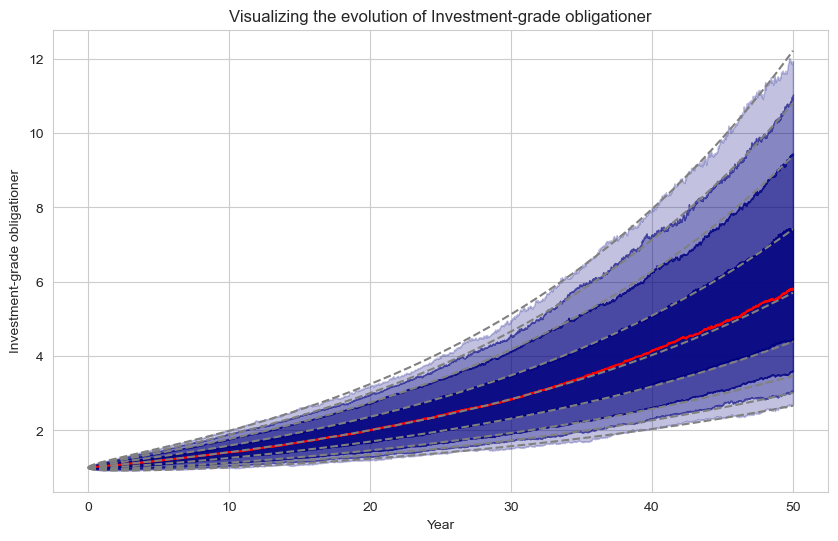

In [28]:
asset_id = 'Investment-grade obligationer'
asset_idx = asset_indices[asset_id]

# calculate simulated percentiles for log-fx
percentiles = np.percentile(sim_data[asset_id], [2.5, 5, 10, 25, 50, 75, 90, 95, 97.5], axis=0)

# calculating analytical percentiles
true_percentiles = np.array([calculate_analytical_percentile(mu_log_weekly[asset_idx], vols_log_weekly[asset_idx], t,
                             q=[0.025, 0.05 , 0.1  , 0.25 , 0.5  , 0.75 , 0.9  , 0.95 , 0.975]) for t in time_points / dt])

fig, ax = plt.subplots(figsize=(10, 6))

fan_chart(time_points, percentiles, ax=ax, color="navy")
ax.plot(time_points, true_percentiles, color="gray", linestyle="--");

ax.set(ylabel=asset_id, xlabel="Year", title="Visualizing the evolution of " + asset_id); 

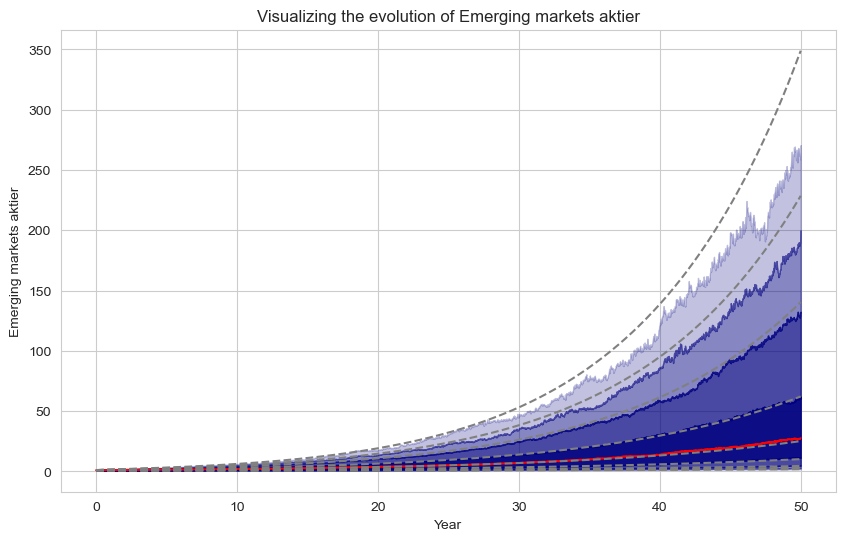

In [24]:
asset_id = 'Emerging markets aktier'
asset_idx = asset_indices[asset_id]

# calculate simulated percentiles for log-fx
percentiles = np.percentile(sim_data[asset_id], [2.5, 5, 10, 25, 50, 75, 90, 95, 97.5], axis=0)
# calculating analytical percentiles
true_percentiles = np.array([calculate_analytical_percentile(mu_log_weekly[asset_idx], vols_log_weekly[asset_idx], t,
                             q=[0.025, 0.05 , 0.1  , 0.25 , 0.5  , 0.75 , 0.9  , 0.95 , 0.975]) for t in time_points / dt])

fig, ax = plt.subplots(figsize=(10, 6))

fan_chart(time_points, percentiles, ax=ax, color="navy")
ax.plot(time_points, true_percentiles, color="gray", linestyle="--");

ax.set(ylabel=asset_id, xlabel="Year", title="Visualizing the evolution of " + asset_id); 

## Calculate risk measures for the assets on a weekly and yearly horizon

We provide the mean, standard deviation, skewness, kurtosis (excess), VaR and CVaR

In [24]:
def calculate_analytical_metrics(mu, vol, alpha=0.05):
        
    dict = {}
    
    dist = stats.lognorm(s=vol, scale=np.exp(mu), loc=-1)

    mean, var, skew, kurt = dist.stats(moments='mvsk')
    std = np.sqrt(var)

    # Value at Risk
    VaR = -1 * dist.ppf(alpha)

    # Conditional Value at Risk
    CVaR = -((np.exp(mu + vol**2 / 2) * stats.norm.cdf(stats.norm.ppf(alpha) - vol)) / alpha - 1)
    
    return {
        'Expected value': mean,
         'Standard deviation': std,
         'Kurtosis': kurt, 
         'Skewness': skew, 
         'VaR({}%)'.format(alpha*100): VaR, 
         'CVaR({}%)'.format(alpha*100): CVaR, 
         'IR': mean / std}

### Weekly horizon

In [25]:
results_weekly = []

for asset, mu, vol in zip(asset_names, mu_log_weekly, vols_log_weekly): 

    metrics = calculate_analytical_metrics(mu, vol)
    metrics['Asset'] = asset

    results_weekly.append(metrics)

df_metrics_weekly = pd.DataFrame(results_weekly).set_index('Asset')

In [26]:
df_metrics_weekly

,Expected value,Standard deviation,Kurtosis,Skewness,VaR(5.0%),CVaR(5.0%),IR
Asset,,,,,,,
Stats- og realkreditobligationer,0.000550,0.004449,0.000316,0.013339,0.006751,0.008593,0.123613
Investment-grade obligationer,0.000699,0.007622,0.000928,0.022851,0.011789,0.014925,0.091698
High-yield obligationer,0.000939,0.012796,0.002615,0.038355,0.019969,0.025179,0.073358
Emerging markets statsobligationer,0.000920,0.012282,0.002409,0.036814,0.019152,0.024158,0.074936
Globale aktier (developed markets),0.001302,0.020396,0.006641,0.061116,0.031887,0.040064,0.063836
Emerging markets aktier,0.001588,0.026368,0.011096,0.078996,0.041183,0.051625,0.060218
Private equity,0.001081,0.026533,0.011247,0.079533,0.041954,0.052458,0.040748
Infrastruktur,0.000937,0.019212,0.005896,0.057588,0.030346,0.038067,0.048766
Ejendomme,0.000699,0.012820,0.002626,0.038435,0.020247,0.025466,0.054520


In [27]:
"""
Check - Covariance matrix and expectation vector
"""

mu_l_weekly = mom.calculate_log_norm_mean(mu_log_weekly, cov_mat_log_weekly) - 1.0
cov_mat_l_weekly = mom.calculate_log_norm_cov_mat(mu_log_weekly, cov_mat_log_weekly)

In [28]:
mu_l_weekly

array([0.00054991, 0.00069894, 0.00093871, 0.00092037, 0.00130197,
       0.00158782, 0.00108119, 0.00093688, 0.00069894, 0.00058541])

### Yearly horizon

In [29]:
results_1y = []

for asset, mu, vol in zip(asset_names, mu_log_1y, vols_log_1y): 

    metrics = calculate_analytical_metrics(mu, vol)
    metrics['Asset'] = asset

    results_1y.append(metrics)

df_metrics_1y = pd.DataFrame(results_1y).set_index('Asset')

In [30]:
df_metrics_1y

,Expected value,Standard deviation,Kurtosis,Skewness,VaR(5.0%),CVaR(5.0%),IR
Asset,,,,,,,
Stats- og realkreditobligationer,0.0290,0.033,0.016472,0.096243,0.024362,0.037278,0.878788
Investment-grade obligationer,0.0370,0.057,0.048478,0.165065,0.054007,0.075280,0.649123
High-yield obligationer,0.0500,0.097,0.137644,0.277931,0.101555,0.135006,0.515464
Emerging markets statsobligationer,0.0490,0.093,0.126687,0.266664,0.096625,0.128953,0.526882
Globale aktier (developed markets),0.0700,0.158,0.356066,0.446210,0.168649,0.217000,0.443038
Emerging markets aktier,0.0860,0.208,0.607414,0.581612,0.219418,0.277201,0.413462
Private equity,0.0578,0.204,0.616137,0.585732,0.241484,0.297989,0.283333
Infrastruktur,0.0499,0.146,0.315060,0.419872,0.171818,0.217344,0.341781
Ejendomme,0.0370,0.096,0.138227,0.278518,0.112975,0.146068,0.385417


In [31]:
"""
Covariance matrix and expectation vector 
"""

mu_l_1y = mom.calculate_log_norm_mean(mu_log_1y, cov_mat_log_1y) - 1.0
cov_mat_l_1y = mom.calculate_log_norm_cov_mat(mu_log_1y, cov_mat_log_1y)

## Calculate risk measures for three different portfolios at weekly and yearly horizon

### Define portfolios

In [32]:
candidate_portfolios = {}

"""
Equally weighted portfolio
"""

# define weights
w_eq = np.ones(num_assets) / num_assets

# store in dictionary
candidate_portfolios['Equally weighted'] = w_eq

In [33]:
"""
Minimum variance portfolios
"""

def calculate_min_var_portfolio(cov_mat: np.ndarray): 
        
    # define target variable
    num_assets = cov_mat.shape[0]
    w = cp.Variable(num_assets)
    
    # define constraints
    constraints = [cp.sum(w) == 1.0, w>=0]
    
    # define problem 
    prob = cp.Problem(cp.Minimize(cp.quad_form(w, cov_mat)), constraints)
    
    # solve
    prob.solve()
    
    if prob.status == 'optimal':
        return w.value
    else:    
        return np.ones(num_assets) * np.nan

# minimum variance portfolio (weekly)
w_min_var_weekly = calculate_min_var_portfolio(cov_mat_l_weekly) 

# minimum variance portfolio (yearly)
w_min_var_1y = calculate_min_var_portfolio(cov_mat_l_1y)

In [34]:
# store in dictionary
candidate_portfolios['Minimum variance'] = w_min_var_1y

In [35]:
"""
Max Sharpe - old
"""

def calculate_max_sharpe_portfolio(mu, cov_mat, rf=0): 

    # negative sharpe ratio
    neg_sharpe_ratio = lambda w: -(mvo.portfolio_mean(w, mu) - rf) / mvo.portfolio_std(w, cov_mat)

    # constraints and bounds
    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    bounds = [(0.0, 1.0) for _ in range(len(mu))]

    # starting values
    w0 = np.ones(len(mu)) / len(mu)

    # minimize negative sharpe ratio
    res = optimize.minimize(neg_sharpe_ratio, w0, method='SLSQP', bounds=bounds, constraints=constraints)
    
    return res.x

def calculate_mean_var_portfolio(mu: np.ndarray, cov_mat: np.ndarray, target): 
        
    # define target variable
    num_assets = cov_mat.shape[0]
    w = cp.Variable(num_assets)
    
    # define constraints
    constraints = [cp.sum(w) == 1.0, w>=0, w @ mu == target]
    
    # define problem 
    prob = cp.Problem(cp.Minimize(cp.quad_form(w, cov_mat)), constraints)
    
    # solve
    prob.solve()
    
    if prob.status == 'optimal':
        return w.value
    else:    
        return np.ones(num_assets) * np.nan

# low
w_mvo_low = calculate_mean_var_portfolio(mu_l_1y, cov_mat_l_1y, 0.035)
candidate_portfolios['MVO 3.5%'] = w_mvo_low

# medium
w_mvo_medium = calculate_mean_var_portfolio(mu_l_1y, cov_mat_l_1y, 0.045)
candidate_portfolios['MVO 4.5%'] = w_mvo_medium

# high
w_mvo_high = calculate_mean_var_portfolio(mu_l_1y, cov_mat_l_1y, 0.065)
candidate_portfolios['MVO 6.5%'] = w_mvo_high

## Summarise Portfolio Weights

In [36]:
df_port_weights = pd.DataFrame(candidate_portfolios,
                               index=asset_names)

In [37]:
df_port_weights.round(3)

,Equally weighted,Minimum variance,MVO 3.5%,MVO 4.5%,MVO 6.5%
Stats- og realkreditobligationer,0.1,0.822,0.778,0.458,-0.000
Investment-grade obligationer,0.1,-0.000,0.002,0.191,0.257
High-yield obligationer,0.1,0.000,0.000,0.000,-0.000
Emerging markets statsobligationer,0.1,-0.000,0.000,0.000,0.035
Globale aktier (developed markets),0.1,0.000,0.047,0.136,0.314
Emerging markets aktier,0.1,0.000,0.042,0.130,0.336
Private equity,0.1,0.000,-0.000,-0.000,-0.000
Infrastruktur,0.1,0.030,0.050,0.063,0.058
Ejendomme,0.1,0.090,0.081,0.022,-0.000
Hedgefonde,0.1,0.058,-0.000,-0.000,-0.000


### Calculate performance and risk metrics

In [38]:
ret_mat_weekly = sim_prices[:, 1, :] - 1.0
ret_mat_1y = sim_prices[:, 52, :] - 1.0

In [39]:
def calculate_portfolio_metrics(w, mu, cov_mat, ret_mat, asset_names=asset_names, alpha=0.05, use_analytical=False):

    # number of assets
    num_assets = len(w)

    # calculate portfolio return 
    port_ret = ret_mat @ w
    
    # Create data frame
    columns = [("Exposure", "Portfolio weights"),
               ("CVaR(5%)", "Standalone"), ("CVaR(5%)", "RC"), ("CVaR(5%)", "MR"),
               ("Expected return", "Standalone"), ("Expected return", "Contribution"),
               ("Std.", "Standalone"), ("Std.", "RC"), ("Std.", "MR"),
               ("Risk-Return", "RoRAC CVaR(5%)"), ("Risk-Return", "RoRAC Std."), 
               #("Risk-Return", "RoMR CVaR(5%)"), ("Risk-Return", "RoMR Std."), 
               ("Risk-Return", "IR CVaR(5%)"), ("Risk-Return", "IR Std.")] # ("Risk-Return", "DI"), 
    
    multi_index = pd.MultiIndex.from_tuples(columns, names=["Category", "Subcategory"])
    
    df_res = pd.DataFrame(columns=multi_index, index=pd.Index(['Portfolio'] + list(asset_names)))

    # exposure
    df_res.loc[:, ('Exposure','Portfolio weights')] = np.r_[1.0, w]

    # CVaR
    df_res.loc['Portfolio', ("CVaR(5%)", "Standalone")] = -rm.calculate_conditional_value_at_risk(port_ret, p=0.05)
    df_res.loc[asset_names, ("CVaR(5%)", "Standalone")] = [-rm.calculate_conditional_value_at_risk(ret_mat[:, i], p=0.05) for i in range(num_assets)]

    df_res.loc[asset_names, ("CVaR(5%)", "RC")] = -rb.calculate_risk_contributions_cvar(w, ret_mat)
    df_res.loc['Portfolio', ("CVaR(5%)", "RC")] = df_res.loc['Portfolio', ("CVaR(5%)", "Standalone")]
    
    df_res.loc[asset_names, ("CVaR(5%)", "MR")] = -rb.calculate_marginal_risks_cvar(w, ret_mat)

    # expected return 
    if use_analytical: 
        df_res.loc[asset_names, ("Expected return", "Standalone")] = mu
        df_res.loc['Portfolio', ("Expected return", "Standalone")] = w @ mu

        df_res.loc[asset_names, ("Expected return", "Contribution")] = mu * w
        df_res.loc['Portfolio', ("Expected return", "Contribution")] = w @ mu
    else: 
        mean_ret = np.mean(ret_mat, axis=0)
        
        df_res.loc[asset_names, ("Expected return", "Standalone")] = mean_ret
        df_res.loc['Portfolio', ("Expected return", "Standalone")] = np.mean(port_ret)

        df_res.loc[asset_names, ("Expected return", "Contribution")] = mean_ret * w
        df_res.loc['Portfolio', ("Expected return", "Contribution")] = np.mean(port_ret)

    # standard devation
    if use_analytical: 
        df_res.loc[asset_names, ("Std.", "Standalone")] = np.sqrt(np.diag(cov_mat))
        df_res.loc['Portfolio', ("Std.", "Standalone")] = np.sqrt(w @ cov_mat @ w)

        df_res.loc[asset_names, ("Std.", "RC")] = rb.calculate_risk_contributions_std(w, cov_mat)
        df_res.loc['Portfolio', ("Std.", "RC")] = np.sqrt(w @ cov_mat @ w)

        df_res.loc[asset_names, ("Std.", "MR")] = rb.calculate_marginal_risks_std(w, cov_mat)
    
    else: 
        cov_mat_est = np.cov(ret_mat.T)
        
        df_res.loc[asset_names, ("Std.", "Standalone")] = np.sqrt(np.diag(cov_mat_est))
        df_res.loc['Portfolio', ("Std.", "Standalone")] = np.sqrt(w @ cov_mat_est @ w)

        df_res.loc[asset_names, ("Std.", "RC")] = rb.calculate_marginal_risks_std(w, cov_mat_est)
        df_res.loc['Portfolio', ("Std.", "RC")] = np.sqrt(w @ cov_mat_est @ w)

        df_res.loc[asset_names, ("Std.", "MR")] = rb.calculate_risk_contributions_std(w, cov_mat_est)

    # risk-return 
    df_res.loc[:, ("Risk-Return", "RoRAC CVaR(5%)")] = df_res.loc[:, ("Expected return", "Contribution")] / df_res.loc[:, ("CVaR(5%)", "RC")]
    df_res.loc[:, ("Risk-Return", "RoRAC Std.")] = df_res.loc[:, ("Expected return", "Contribution")] / df_res.loc[:, ("Std.", "RC")]

    #df_res.loc[asset_names, ("Risk-Return", "RoMR CVaR(5%)")] = df_res.loc[:, ("Expected return", "Standalone")] / df_res.loc[:, ("CVaR(5%)", "MR")]
    #df_res.loc[asset_names, ("Risk-Return", "RoMR Std.")] = df_res.loc[:, ("Expected return", "Standalone")] / df_res.loc[:, ("Std.", "MR")]
    
    df_res.loc[:, ("Risk-Return", "IR CVaR(5%)")] = df_res.loc[:, ("Expected return", "Standalone")] / df_res.loc[:, ("CVaR(5%)", "Standalone")]
    df_res.loc[:, ("Risk-Return", "IR Std.")] = df_res.loc[:, ("Expected return", "Standalone")] / df_res.loc[:, ("Std.", "Standalone")]

    # df_res.loc[asset_names, ("Expected return", "Contribution")] / df_res.loc[asset_names, ("Expected return", "Contribution")]
    
    return df_res

In [40]:
"""
Equally weighted portfolio
"""

df_port_metrics_eq = calculate_portfolio_metrics(w_eq, mu_l_1y, cov_mat_l_1y, ret_mat_1y, asset_names=asset_names, alpha=0.05, use_analytical=True)
df_port_metrics_eq

AttributeError: module 'codelib.Johan.portfolio_optimization.risk_metrics' has no attribute 'calculate_risk_contributions_cvar'

In [45]:
"""
Minimum variance portfolio
"""

df_port_metrics_min_var = calculate_portfolio_metrics(w_min_var_1y, mu_l_1y, cov_mat_l_1y, ret_mat_1y, asset_names=asset_names, alpha=0.05, use_analytical=True)
df_port_metrics_min_var

AttributeError: module 'codelib.Johan.portfolio_optimization.risk_metrics' has no attribute 'calculate_risk_contributions_cvar'

In [46]:
df_port_metrics_low = calculate_portfolio_metrics(w_mvo_low, mu_l_1y, cov_mat_l_1y, ret_mat_1y, asset_names=asset_names, alpha=0.05, use_analytical=True)
df_port_metrics_low

AttributeError: module 'codelib.Johan.portfolio_optimization.risk_metrics' has no attribute 'calculate_risk_contributions_cvar'

In [47]:
df_port_metrics_medium = calculate_portfolio_metrics(w_mvo_medium, mu_l_1y, cov_mat_l_1y, ret_mat_1y, asset_names=asset_names, alpha=0.05, use_analytical=True)
df_port_metrics_medium

AttributeError: module 'codelib.Johan.portfolio_optimization.risk_metrics' has no attribute 'calculate_risk_contributions_cvar'

In [48]:
df_port_metrics_high = calculate_portfolio_metrics(w_mvo_high, mu_l_1y, cov_mat_l_1y, ret_mat_1y, asset_names=asset_names, alpha=0.05, use_analytical=True)
df_port_metrics_high

AttributeError: module 'codelib.Johan.portfolio_optimization.risk_metrics' has no attribute 'calculate_risk_contributions_cvar'

### Plots for visualization

In [ ]:
w_to_plot = candidate_portfolios['Equally weighted']

### Standard Deviation

In [ ]:
rc_std = rb.calculate_risk_contributions_std(w_to_plot, cov_mat_linear_1y)

In [ ]:
fig, ax = waterfall_chart(values=rc_std*100,
                          labels=asset_names,
                          formatting='{:,.1f}%',
                          total_label="Total risk (std)")

ax.set(ylabel="Risk contribution", title="Risk contribution using std. as risk measure")

fig.set_size_inches(12, 6);

### Conditional Value at Risk

In [ ]:
rc_cvar = rb.calculate_risk_contributions_cvar(w_to_plot, ret_mat_1y)

In [ ]:
fig, ax = waterfall_chart(values=-rc_cvar*100,
                          labels=asset_names,
                          formatting='{:,.1f}%',
                          total_label="Total risk (CVaR(5%))")

ax.set(ylabel="Risk contribution", title="Risk contribution using CVaR(5%) as risk measure")

fig.set_size_inches(12, 6);

### Select optimal portfolio

In [ ]:
def calculate_aggregate_portfolio_metrics(portfolios, mu, cov_mat, ret_mat, alpha=0.05, use_analytical=False):


    # Create data frame
    columns = ["Std.",
               "CVaR(5%)",
               "Expected return",
               "IR CVaR(5%)",
               "IR Std."]

    df_res = pd.DataFrame(columns=columns, index=list(portfolios.keys()))

    for port_name, w in portfolios.items():

        # number of assets
        num_assets = len(w)

        # calculate portfolio return
        port_ret = ret_mat @ w

        # CVaR
        df_res.loc[port_name, "CVaR(5%)"] = -rm.calculate_conditional_value_at_risk(port_ret, p=0.05)

        # expected return
        if use_analytical:
            df_res.loc[port_name, "Expected return"] = w @ mu
        else:
            mean_ret = np.mean(ret_mat, axis=0)
            df_res.loc[port_name, "Expected return"] = w @ mean_ret

        # standard devation
        if use_analytical:
            df_res.loc[port_name, "Std."] = np.sqrt(w @ cov_mat @ w)
        else:
            cov_mat_est = np.cov(ret_mat.T)
            df_res.loc[port_name, "Std."] = np.sqrt(w @ cov_mat_est @ w)

    df_res.loc[:, "IR CVaR(5%)"] = df_res.loc[:, "Expected return"] / df_res.loc[:, "CVaR(5%)"]
    df_res.loc[:, "IR Std."] = df_res.loc[:, "Expected return"] / df_res.loc[:, "Std."]

    return df_res

In [ ]:
"""
Add small table with Expected return, CVaR, Ratio and indicator
"""

df_agg_port_metrics = calculate_aggregate_portfolio_metrics(candidate_portfolios,
                                                            mu_l_1y,
                                                            cov_mat_l_1y,
                                                            ret_mat_1y,
                                                            alpha=0.05,
                                                            use_analytical=True)

In [ ]:
df_agg_port_metrics

## Simulate CVaR of portfolio for the next 10 year

We perform the calculation relative to the market value of the portfolio, but with updated weights.

In [ ]:
"""
Select the portfolio
"""

port_name = 'Equally weighted'
w_to_plot = candidate_portfolios[port_name]

In [51]:
"""
Calculate portfolio value 
"""

sim_portfolio_value = sim_prices @ w_to_plot

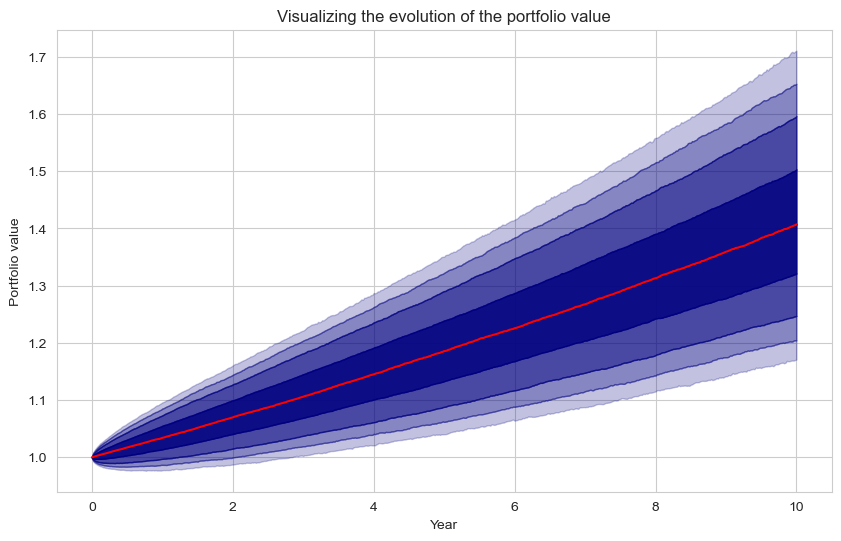

In [52]:
"""
Visualise evolution of portfolio value
"""

percentiles = np.percentile(sim_portfolio_value, [2.5, 5, 10, 25, 50, 75, 90, 95, 97.5], axis=0)

fig, ax = plt.subplots(figsize=(10, 6))

fan_chart(time_points, percentiles, ax=ax, color="navy")

ax.set(ylabel='Portfolio value', xlabel="Year",
       title="Visualizing the evolution of the portfolio value - " + port_name);

In [53]:
"""
Evolution in portfolio weights
"""

sim_w = sim_prices * w_to_plot[None, None, :] / sim_portfolio_value[:, :, None]


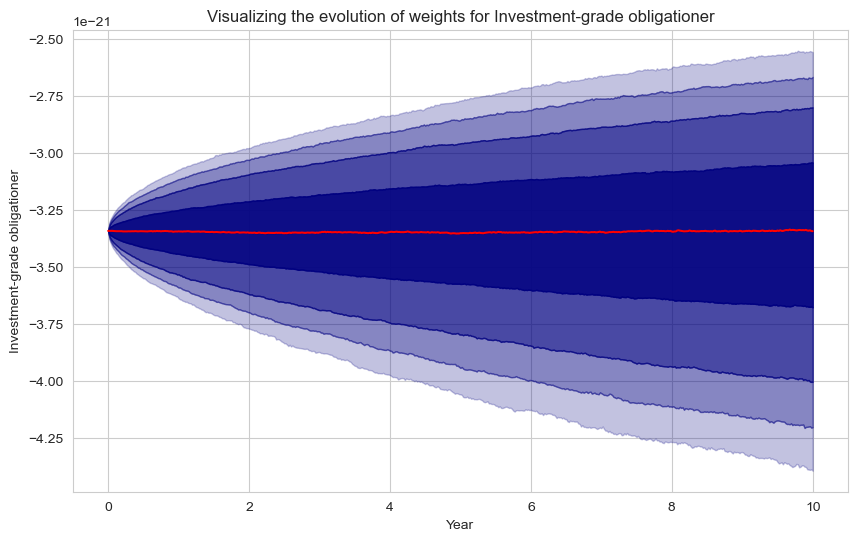

In [54]:
"""
Visualize evolution in portfolio weights
"""

asset_id = 'Government bonds'
asset_idx = asset_indices[asset_id]

percentiles = np.percentile(sim_w[:, :, asset_idx], [2.5, 5, 10, 25, 50, 75, 90, 95, 97.5], axis=0)

fig, ax = plt.subplots(figsize=(10, 6))

fan_chart(time_points, percentiles, ax=ax, color="navy")

ax.set(ylabel=asset_id, xlabel="Year", title="Visualizing the evolution of weights for " + asset_id); 

In [55]:
from joblib import Parallel, delayed
# import multiprocessing as mp

In [56]:
"""
Simulate CVaR(5%, 1Y)
"""

horison_in_weeks = 52 * 1
num_sim_to_use = 10_000
sim_cvar = np.zeros((num_sim_to_use, horison_in_weeks + 1))
cvar_time_points = np.arange(0, horison_in_weeks * dt + dt, dt)

#for s in range(num_sim_to_use):
#    for t in range(horison_in_weeks + 1): 
#        sim_cvar[s, t] = -rm.calculate_conditional_value_at_risk(ret_mat_1y @ sim_w[s, t, :], p=0.05)

def compute_simulation_row(s):
    row = np.zeros(horison_in_weeks + 1)
    for t in range(horison_in_weeks + 1):
        row[t] = -rm.calculate_conditional_value_at_risk(ret_mat_1y @ sim_w[s, t, :], p=0.05)
    return row

results = Parallel(n_jobs=-1)(
    delayed(compute_simulation_row)(s) for s in range(num_sim_to_use)
)

sim_cvar = np.array(results)

KeyboardInterrupt: 

In [369]:
cvar_time_points = np.arange(0, horison_in_weeks * dt + dt, dt)

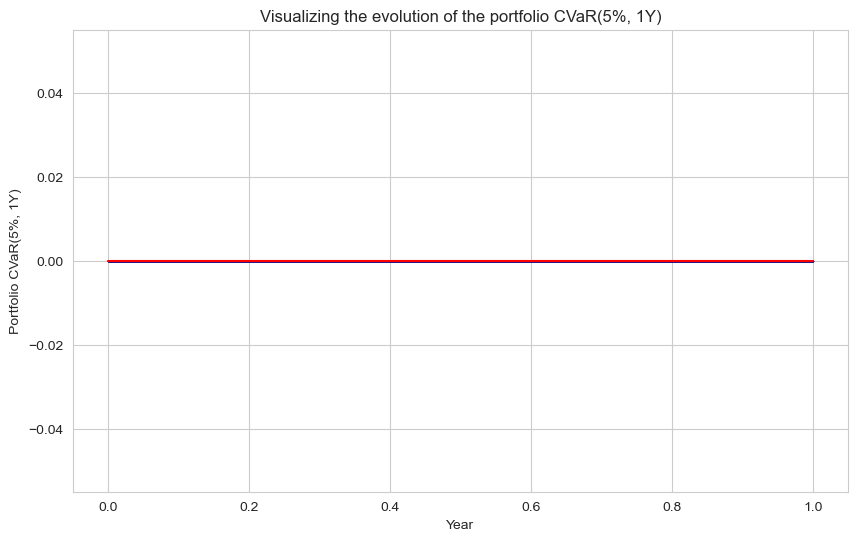

In [69]:
"""
Visualise evolution of portfolio value
"""

percentiles = np.percentile(sim_cvar * 100, [2.5, 5, 10, 25, 50, 75, 90, 95, 97.5], axis=0)

fig, ax = plt.subplots(figsize=(10, 6))

fan_chart(cvar_time_points, percentiles, ax=ax, color="navy")

ax.set(ylabel='Portfolio CVaR(5%, 1Y)',
       xlabel="Year",
       title="Visualizing the evolution of the portfolio CVaR(5%, 1Y)");

## Distribution of realized Sharpe ratios, etc.

In [70]:
"""
Calculate portfolio period return
"""

sim_port_ret = sim_portfolio_value[:, 1:] / sim_portfolio_value[:, :-1] - 1.0

"""
Calculate relevant metrics
"""

sim_port_std = np.std(sim_port_ret, axis=1)
sim_port_ar_ret = np.mean(sim_port_ret, axis=1)
sim_port_sharpe = sim_port_ar_ret / sim_port_std
#sim_port_geo_ret = sim_portfolio_value[:, -1]**(1 / 5.0) - 1.0
sim_port_geo_ret = sim_portfolio_value[:, -1]**(1 / (5.0 * 52.0)) - 1.0

<Axes: ylabel='Density'>

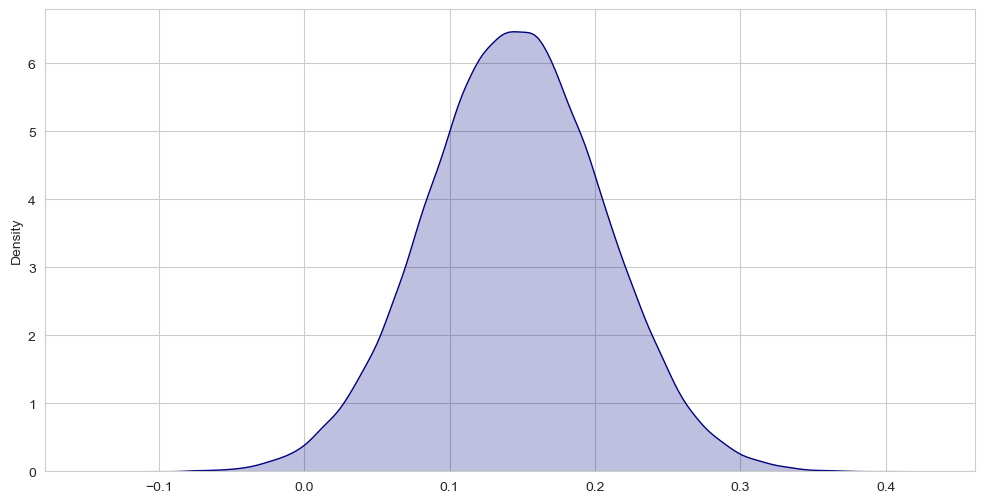

In [71]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.kdeplot(sim_port_sharpe, fill=True, color='navy');

ax.set_title('Distribution of realized Sharpe ratios - ' + port_name)
ax.set_xlabel('Sharpe ratios');

<Axes: ylabel='Density'>

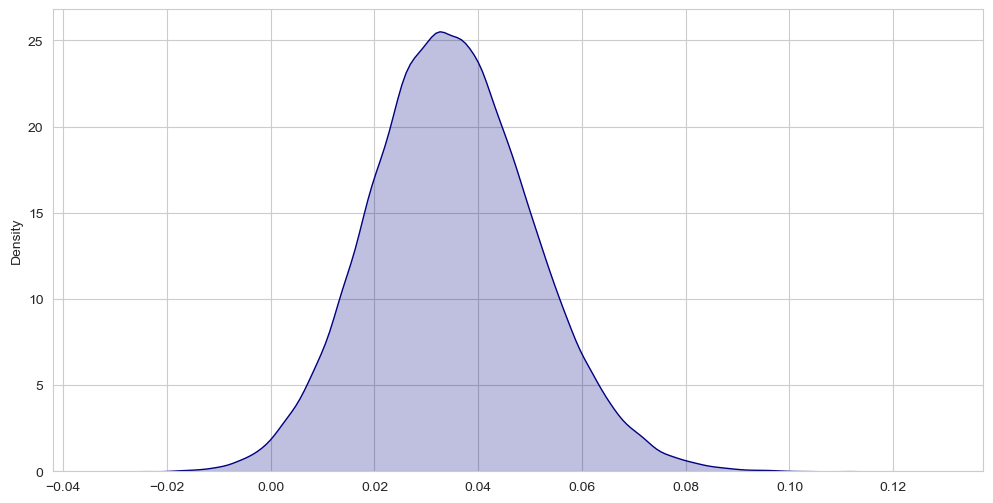

In [72]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.kdeplot(sim_port_geo_ret, fill=True, color='navy');
ax.set_title('Distribution of realized geometric returns - ' + port_name)
ax.set_xlabel('Geometric returns');